In [ ]:
# 1. LIBRERÍAS Y CONFIGURACIÓN
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import joblib

# Scikit-Learn
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import plot_tree
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [3]:
# Carga de datos
df = pd.read_parquet(Path(r"D:\ProyectoAnalisisElectrico\Cmg\TrainMacrozona.parquet"))
df = df.drop(columns=["tension", "nombre_barra", "CMg[CLP/KWh]", "Periodo", "CMg[CLP/KWh]_mes", "CMg[CLP/KWh]_period", "Año"], errors = "ignore")
df.columns=["name", "hora", "cmg", "mes", "cmg_mes", "cmg_period", "macrozona"]

# Cálculo de Rampas
df_ordenado = df.sort_values(['name', 'mes', 'hora'])
df_ordenado['Rampa'] = df_ordenado.groupby('name')['cmg'].diff()
df_rampas = df_ordenado.groupby('name').agg(
    rampa_max_subida=('Rampa', 'max'),
    rampa_max_bajada=('Rampa', 'min')
).reset_index()

# Perfil 24 Horas
df_24h = df.groupby(["name", "hora"])["cmg"].mean().reset_index()
df_24h_pivot = df_24h.pivot(index="name", columns="hora", values="cmg").reset_index()
df_24h_pivot.columns = ["name"] + [f"hora_{int(h)}" for h in df_24h_pivot.columns[1:]]

# Perfil 12 Meses
df_mes = df.groupby(["name", "mes"])["cmg"].mean().reset_index()
df_mes_pivot = df_mes.pivot(index="name", columns="mes", values="cmg").reset_index()
df_mes_pivot.columns = ["name"] + [f"mes_{int(m)}" for m in df_mes_pivot.columns[1:]]

# Consolidación final del Dataset Wide
df_base = df[['name', 'macrozona']].drop_duplicates()
dff = pd.merge(df_base, df_rampas, on="name")
dff = pd.merge(dff, df_24h_pivot, on="name")
dff = pd.merge(dff, df_mes_pivot, on="name")

# Separar Variables Predictoras (X) de Objetivo (y)
X = dff.drop(columns=['name', 'macrozona'])
y = dff['macrozona']

# Codificar las variables categóricas (Macrozonas)
le = LabelEncoder()
y_num = le.fit_transform(y)

dff.head(3)

,name,macrozona,rampa_max_subida,rampa_max_bajada,hora_1,hora_2,hora_3,hora_4,hora_5,hora_6,...,mes_3,mes_4,mes_5,mes_6,mes_7,mes_8,mes_9,mes_10,mes_11,mes_12
0,A_____________100,Norte Grande,74.936885,-75.577014,69.960049,69.502326,70.304445,70.677094,70.318435,72.261852,...,33.877745,38.317423,56.345685,57.450516,59.886880,36.001269,37.198695,36.454216,42.300210,33.608278
1,A.BLANCAS_____013,Centro Sur,65.965487,-58.319837,71.838979,68.897581,67.056105,65.430877,65.510684,68.252664,...,42.546068,45.171947,63.632331,113.054316,93.336482,47.251484,41.447338,32.723888,47.718020,39.558931
2,A.BLANCAS_____066,Centro Sur,65.631527,-58.186356,71.569747,68.669095,66.850607,65.242480,65.324337,68.053178,...,42.389961,45.025085,63.164197,112.271285,92.882392,47.059810,41.335384,32.612467,47.540742,39.420933


In [4]:
def procesar_features(df_in, valor_referencia=None):
    df_out = df_in.copy()
    cols_horas = [f"hora_{i}" for i in range(1, 25)]
    cols_meses = [f"mes_{i}" for i in range(1, 13)]
    cols_rampas = ['rampa_max_subida', 'rampa_max_bajada']
    
    # Calcular máximo por barra para estandarizar
    max_por_barra = df_out[cols_horas].max(axis=1).replace(0, 1)
    
    # Si no hay referencia (Train), calculamos la mediana
    if valor_referencia is None:
        valor_referencia = max_por_barra.median()

    # Normalización de magnitud relativa al sistema
    df_out['factor_magnitud'] = max_por_barra / valor_referencia
    
    for col in cols_horas + cols_meses + cols_rampas:
        df_out[col] = df_out[col] / max_por_barra
        
    return df_out.fillna(-1), valor_referencia

In [5]:
df_testing = pd.read_parquet(Path(r"D:\ProyectoAnalisisElectrico\Cmg\TestMacrozona.parquet"))

# Renombrar y Limpiar
df_test_clean = pd.DataFrame()
df_test_clean['name'] = df_testing['nombre_barra_cmg']
df_test_clean['hora'] = pd.to_numeric(df_testing['HORA']).astype(int)
df_test_clean['cmg'] = pd.to_numeric(df_testing['CMg[USD/MWh]'])
df_test_clean['mes'] = pd.to_numeric(df_testing['Mes']).astype(int)
df_test_clean['macrozona'] = df_testing['Macrozona'] 

# Compresión a Formato Ancho (Replicando pasos de Train)
df_test_ord = df_test_clean.sort_values(['name', 'mes', 'hora'])
df_test_ord['Rampa'] = df_test_ord.groupby('name')['cmg'].diff()
df_test_rampas = df_test_ord.groupby('name').agg(rampa_max_subida=('Rampa', 'max'), rampa_max_bajada=('Rampa', 'min')).reset_index()

df_test_24h = df_test_clean.groupby(["name", "hora"])["cmg"].mean().reset_index()
df_test_24h_pivot = df_test_24h.pivot(index="name", columns="hora", values="cmg").reset_index()
df_test_24h_pivot.columns = ["name"] + [f"hora_{int(h)}" for h in df_test_24h_pivot.columns[1:]]

df_test_mes = df_test_clean.groupby(["name", "mes"])["cmg"].mean().reset_index()
df_test_mes_pivot = df_test_mes.pivot(index="name", columns="mes", values="cmg").reset_index()
df_test_mes_pivot.columns = ["name"] + [f"mes_{int(m)}" for m in df_test_mes_pivot.columns[1:]]

df_test_base = df_test_clean[['name', 'macrozona']].drop_duplicates()
dff_test_wide = pd.merge(df_test_base, df_test_rampas, on="name")
dff_test_wide = pd.merge(dff_test_wide, df_test_24h_pivot, on="name")
dff_test_wide = pd.merge(dff_test_wide, df_test_mes_pivot, on="name")

# Preparar características e igualar estructura a Train
X_test_raw = dff_test_wide.drop(columns=['name', 'macrozona'])
X_test_raw = X_test_raw.reindex(columns=X.columns)
y_test_raw = dff_test_wide['macrozona']
y_test_num = le.transform(y_test_raw)

In [6]:
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

train_accuracies = []
val_accuracies = []
test_accuracies = []

print("Iniciando validación cruzada (max_depth=6)...\n")

for fold, (train_index, val_index) in enumerate(skf.split(X, y_num)):
    X_train, X_val = X.iloc[train_index], X.iloc[val_index]
    y_train, y_val = y_num[train_index], y_num[val_index]
    
    # Procesar características respetando aislamiento
    X_train_norm, ref_sistema = procesar_features(X_train)
    X_val_norm, _ = procesar_features(X_val, valor_referencia=ref_sistema)
    X_test_norm, _ = procesar_features(X_test_raw, valor_referencia=ref_sistema)
    
    # Entrenar modelo
    rf_cv = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=6)
    rf_cv.fit(X_train_norm, y_train)
    
    # Evaluar
    acc_train = rf_cv.score(X_train_norm, y_train)
    acc_val = rf_cv.score(X_val_norm, y_val)
    acc_test = rf_cv.score(X_test_norm, y_test_num) 
    
    train_accuracies.append(acc_train)
    val_accuracies.append(acc_val)
    test_accuracies.append(acc_test)
    
    print(f"Fold {fold + 1} | Train: {acc_train * 100:.2f}% | Val: {acc_val * 100:.2f}% | Test: {acc_test * 100:.2f}%")

print("\n" + "="*50)
print("RESULTADOS GLOBALES PROMEDIO")
print("="*50)
print(f"Train: {np.mean(train_accuracies) * 100:.2f}%")
print(f"Val:   {np.mean(val_accuracies) * 100:.2f}%")
print(f"Test:  {np.mean(test_accuracies) * 100:.2f}%")

Iniciando validación cruzada (max_depth=6)...

Fold 1 | Train: 97.74% | Val: 96.61% | Test: 98.20%
Fold 2 | Train: 97.60% | Val: 96.61% | Test: 97.30%
Fold 3 | Train: 97.88% | Val: 91.53% | Test: 96.85%
Fold 4 | Train: 98.44% | Val: 94.35% | Test: 97.30%
Fold 5 | Train: 97.74% | Val: 94.32% | Test: 98.20%

RESULTADOS GLOBALES PROMEDIO
Train: 97.88%
Val:   94.68%
Test:  97.57%


--- REPORTE DE CLASIFICACIÓN (TEST FINAL) ---
Exactitud Oficial Definitiva (Test): 97.30%

              precision    recall  f1-score   support

      Centro       0.97      0.94      0.95        63
  Centro Sur       0.94      0.97      0.96        66
 Norte Chico       1.00      1.00      1.00        25
Norte Grande       1.00      1.00      1.00        34
         Sur       1.00      1.00      1.00        34

    accuracy                           0.97       222
   macro avg       0.98      0.98      0.98       222
weighted avg       0.97      0.97      0.97       222



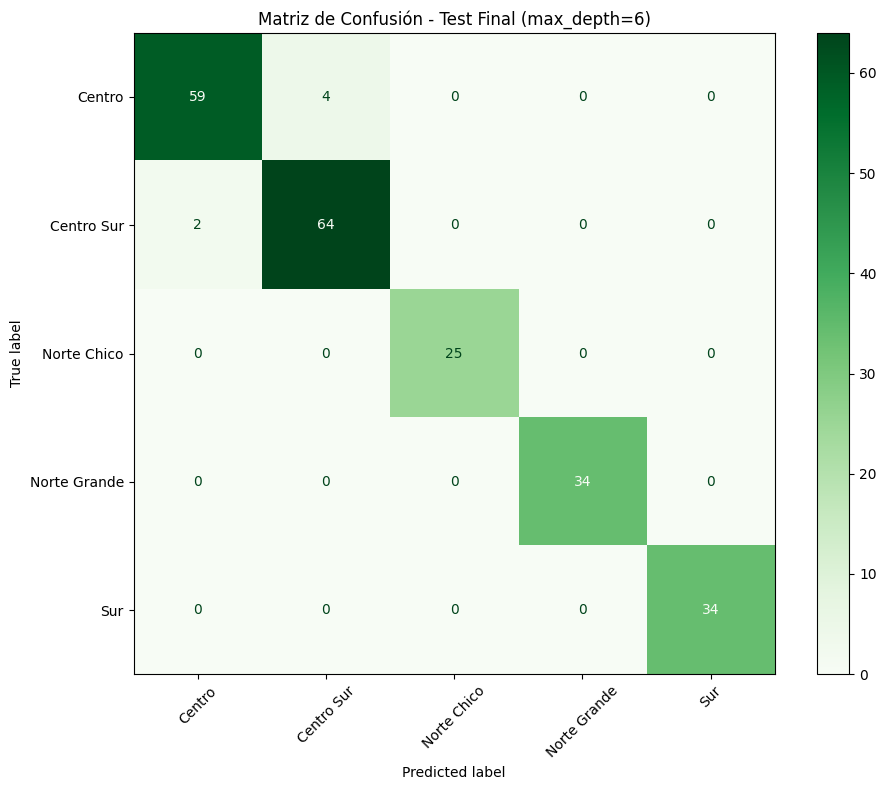

In [7]:
# 1. Procesamiento Global
X_completo_norm, ref_sistema_final = procesar_features(X)
X_test_norm_final, _ = procesar_features(X_test_raw, valor_referencia=ref_sistema_final)

# 2. Entrenamiento
rf_final = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=6)
rf_final.fit(X_completo_norm, y_num)

# 3. Predicción y Reporte
y_pred_test = rf_final.predict(X_test_norm_final)
score_final = rf_final.score(X_test_norm_final, y_test_num)

print("--- REPORTE DE CLASIFICACIÓN (TEST FINAL) ---")
print(f"Exactitud Oficial Definitiva (Test): {score_final * 100:.2f}%\n")
print(classification_report(y_test_num, y_pred_test, target_names=le.classes_))

# 4. Matriz de Confusión
cm = confusion_matrix(y_test_num, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)

fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(cmap='Greens', xticks_rotation=45, ax=ax, values_format='d')
plt.title("Matriz de Confusión - Test Final (max_depth=6)")
plt.tight_layout()
plt.show()

In [9]:
model_dir = Path(r'D:\ProyectoAnalisisElectrico\Modelos\ModeloSegmentacion')
model_dir.mkdir(parents=True, exist_ok=True)

joblib.dump(rf_final, model_dir / 'rf_model_energia_d6_full.joblib')
joblib.dump(le, model_dir / 'label_encoder_energia_d6_full.joblib')
# Se recomienda guardar también la referencia
joblib.dump(ref_sistema_final, model_dir / 'valor_referencia_full.joblib') 


['D:\\ProyectoAnalisisElectrico\\Modelos\\ModeloSegmentacion\\valor_referencia_full.joblib']

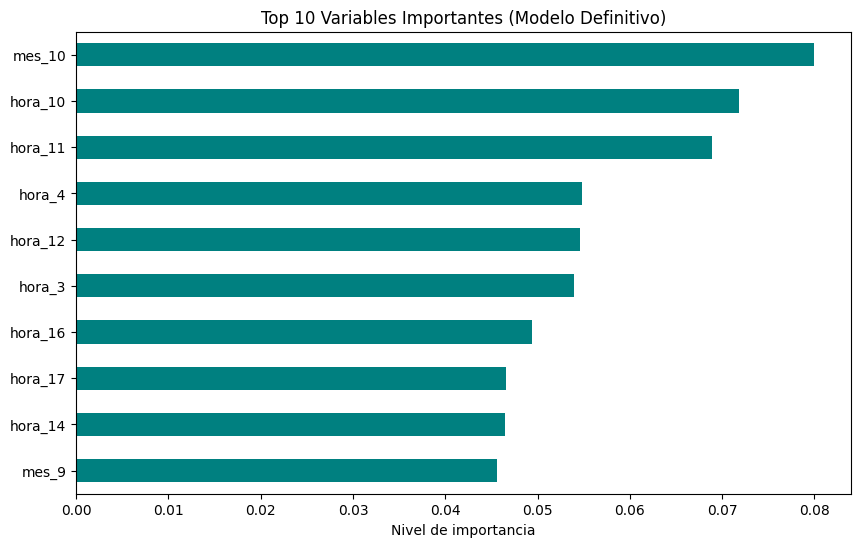

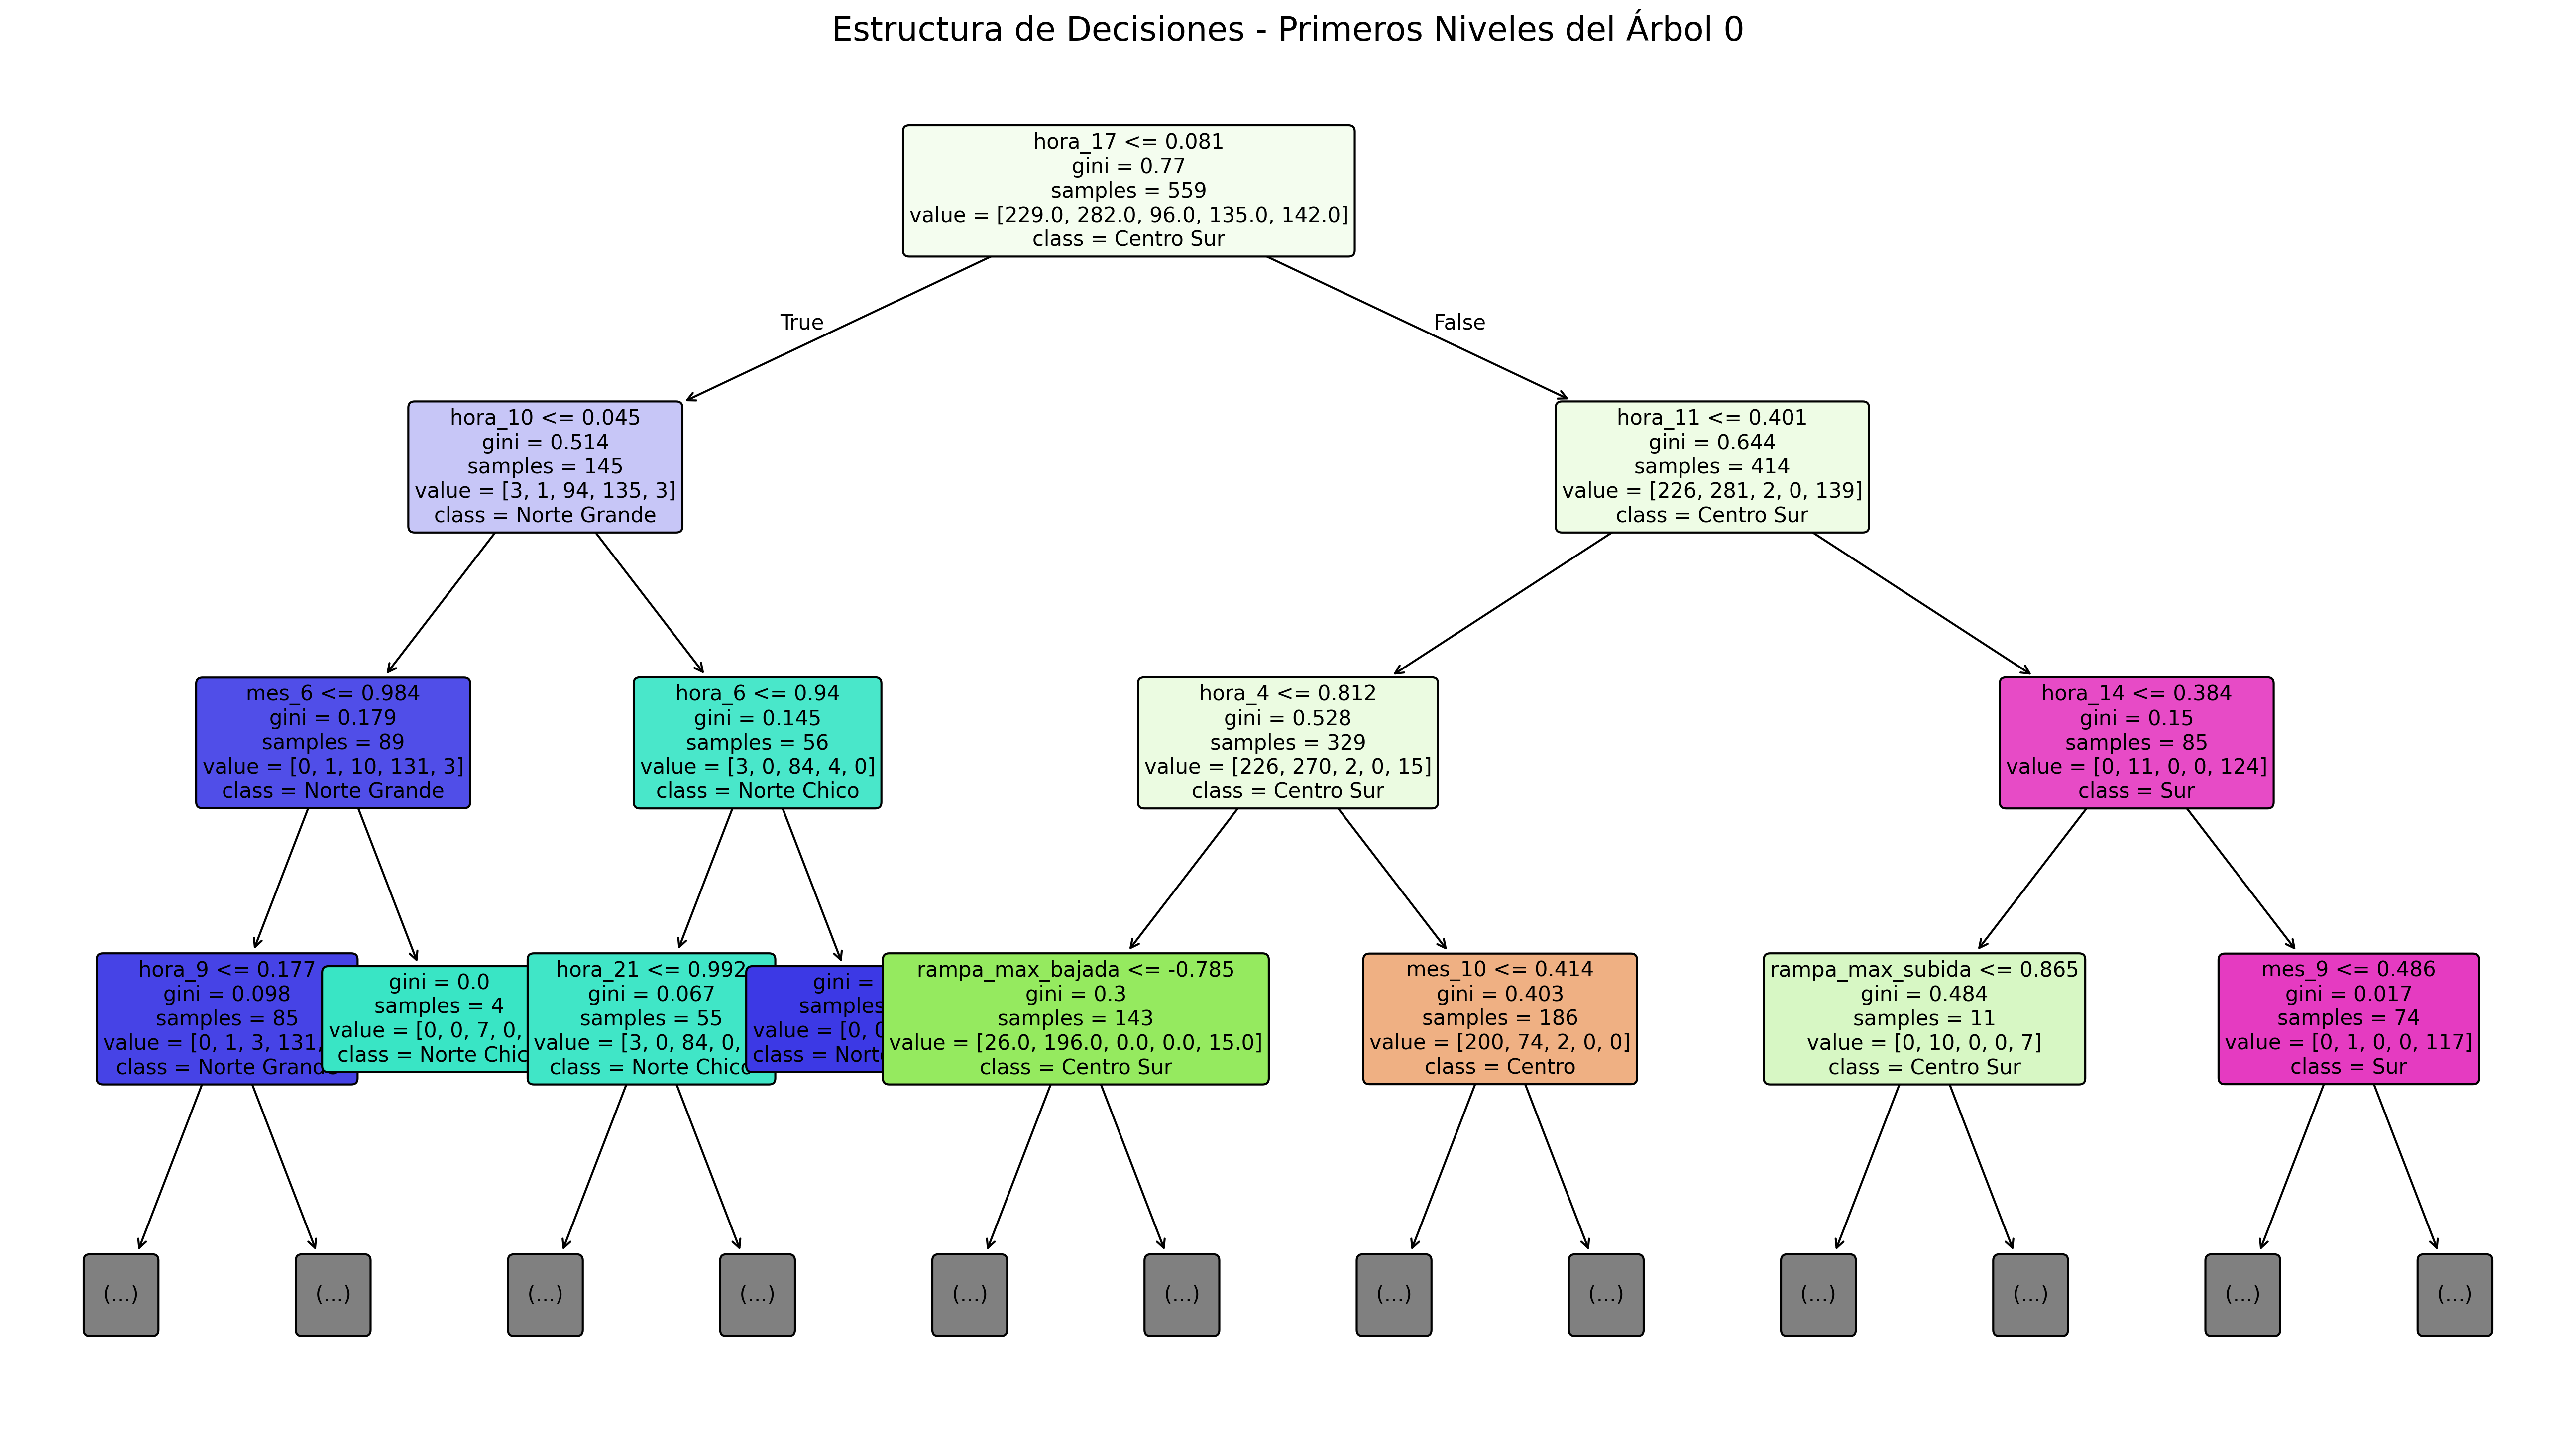

In [10]:
# Importancia de Variables
plt.figure(figsize=(10, 6))
importancias = pd.Series(rf_final.feature_importances_, index=X_completo_norm.columns)
importancias.nlargest(10).sort_values().plot(kind='barh', color='teal')
plt.title("Top 10 Variables Importantes (Modelo Definitivo)")
plt.xlabel("Nivel de importancia")
plt.show()

# Visualización del Árbol de Decisión (Primeros niveles de un estimador)
un_arbol = rf_final.estimators_[0]
fig, ax = plt.subplots(figsize=(22, 12), dpi=300)

plot_tree(
    un_arbol,
    max_depth=3,  # Limitado a 3 para legibilidad
    feature_names=list(X_completo_norm.columns),
    class_names=list(le.classes_),
    filled=True,
    rounded=True,
    fontsize=10,
    ax=ax
)
plt.title("Estructura de Decisiones - Primeros Niveles del Árbol 0", fontsize=16)
plt.show()

--- REPORTE DE CLASIFICACIÓN: BASELINE (NAIVE BAYES) ---
              precision    recall  f1-score   support

      Centro       0.63      0.98      0.77        63
  Centro Sur       0.68      0.45      0.55        66
 Norte Chico       0.92      0.96      0.94        25
Norte Grande       0.97      0.97      0.97        34
         Sur       1.00      0.59      0.74        34

    accuracy                           0.76       222
   macro avg       0.84      0.79      0.79       222
weighted avg       0.79      0.76      0.75       222



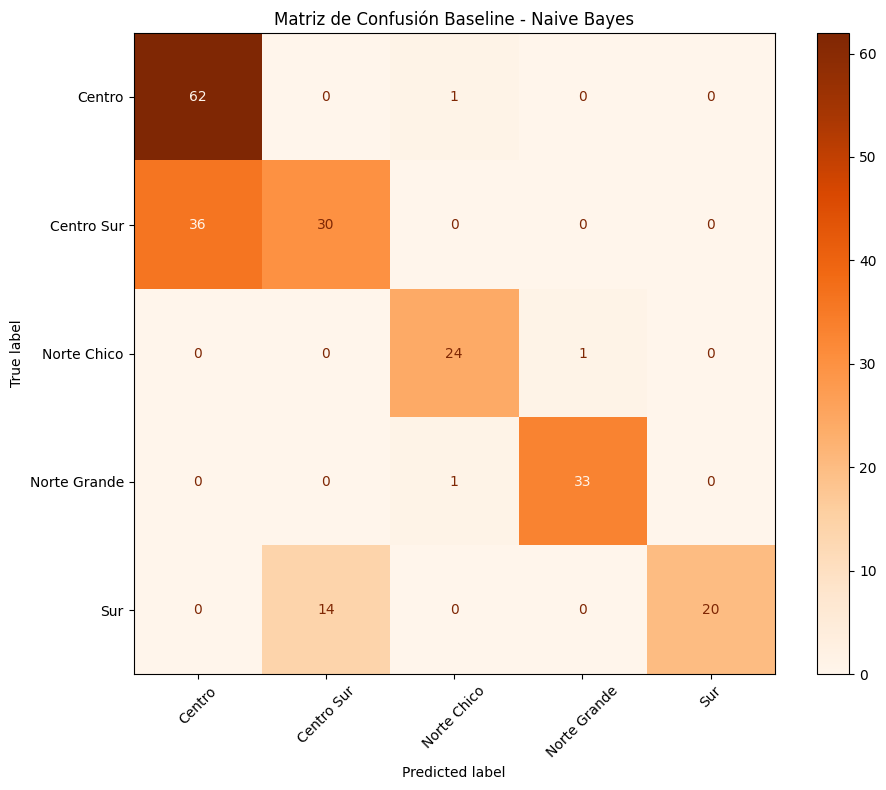

In [11]:
# Entrenamos Naive Bayes sobre la data completa
nb_model = GaussianNB()
nb_model.fit(X_completo_norm, y_num)

y_pred_nb = nb_model.predict(X_test_norm_final)

print("--- REPORTE DE CLASIFICACIÓN: BASELINE (NAIVE BAYES) ---")
print(classification_report(y_test_num, y_pred_nb, target_names=le.classes_))

cm_nb = confusion_matrix(y_test_num, y_pred_nb)
disp_nb = ConfusionMatrixDisplay(confusion_matrix=cm_nb, display_labels=le.classes_)

fig, ax = plt.subplots(figsize=(10, 8))
disp_nb.plot(cmap='Oranges', ax=ax, xticks_rotation=45)
plt.title("Matriz de Confusión Baseline - Naive Bayes")
plt.tight_layout()
plt.show()